In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('h233.csv',low_memory=False)

In [3]:
df.head()

,DUID,PID,DUPERSID,PANEL,FAMID31,FAMID42,FAMID53,FAMID21,FAMIDYR,CPSFAMID,...,RXPTR21,RXOTH21,PERWT21F,FAMWT21F,FAMWT21C,SAQWT21F,DIABW21F,SDOHWT21F,VARSTR,VARPSU
0,2320005,101,2320005101,23,A,A,A,A,A,A,...,0,0,6785.015684,7187.249055,7187.249055,0.0,0.0,8941.111966,2079,1
1,2320005,102,2320005102,23,A,A,A,A,A,A,...,0,0,6176.506584,7187.249055,7187.249055,0.0,0.0,0.000000,2079,1
2,2320006,101,2320006101,23,A,A,A,A,A,A,...,0,0,1599.364175,1530.856371,1530.856371,0.0,0.0,1990.417108,2028,1
3,2320006,102,2320006102,23,B,B,B,B,B,B,...,0,0,1649.344739,2314.506726,2314.506726,0.0,0.0,2317.855238,2028,1
4,2320006,103,2320006103,23,A,A,A,A,A,A,...,0,0,2891.997868,1530.856371,1530.856371,0.0,0.0,2708.864797,2028,1


In [4]:
# Keep spending column
spending = df["TOTEXP21"].dropna()

# Summary statistics
summary = {
    "Total Spending (All Respondents)": spending.sum(),
    " Average Spending per Person": spending.mean(),
    " Median Spending per Person": spending.median(),
    " Max Spending (Highest Patient)": spending.max(),
    " Standard Deviation": spending.std()
}

print(summary)

{'Total Spending (All Respondents)': 218489049, ' Average Spending per Person': 7710.652491530209, ' Median Spending per Person': 1504.5, ' Max Spending (Highest Patient)': 2187290, ' Standard Deviation': 27282.774757384606}


In [5]:
# List of expenditure variables
exp_vars = ['TOTTCH21', 'TOTEXP21', 'TOTSLF21', 'TOTMCR21', 'TOTMCD21',
            'TOTPRV21', 'TOTVA21', 'TOTTRI21', 'TOTOFD21', 'TOTSTL21',
            'TOTWCP21', 'TOTOSR21', 'TOTPTR21', 'TOTOTH21',
            'OBTOTV21', 'OPTOTV21', 'OPTOTH21', 'ERTOT21', 'ERTOTH21',
            'IPDIS21', 'IPTOTH21', 'DVTOT21', 'DVTOTH21',
            'HHTOTD21', 'RXTOT21']

# Replace special codes with NaN
df[exp_vars] = df[exp_vars].replace([-1, -7, -8, -9], np.nan)

# Check summary after cleaning
print(df[exp_vars].describe())

           TOTTCH21      TOTEXP21       TOTSLF21      TOTMCR21      TOTMCD21  \
count  2.833600e+04  2.833600e+04   28336.000000  2.833600e+04  2.833600e+04   
mean   1.618220e+04  7.710652e+03     886.748765  2.621313e+03  1.132033e+03   
std    6.357760e+04  2.728277e+04    3162.920935  1.593783e+04  1.465972e+04   
min    0.000000e+00  0.000000e+00       0.000000  0.000000e+00  0.000000e+00   
25%    3.010000e+02  2.420000e+02       0.000000  0.000000e+00  0.000000e+00   
50%    2.102000e+03  1.504500e+03     128.000000  0.000000e+00  0.000000e+00   
75%    9.584000e+03  6.143000e+03     729.000000  7.925000e+01  0.000000e+00   
max    4.696821e+06  2.187290e+06  169281.000000  1.666535e+06  2.186078e+06   

            TOTPRV21        TOTVA21      TOTTRI21      TOTOFD21  \
count   28336.000000   28336.000000  28336.000000  28336.000000   
mean     2595.375529     233.741318     60.953910     20.055654   
std     13350.402316    3879.368580    937.076731    566.936082   
min        

# !!we are not going to remove outliers cause we want real-world insights . 

#  Overall Spending !

### 1] Average total annual healthcare expenditure per person.

In [6]:
# Keep only valid expenditure values
expenditures = df["TOTEXP21"]
expenditures = expenditures.replace([-1, -7, -8, -9], pd.NA).dropna()

# Average spending per person
average_spending = expenditures.mean()

print(f"Average Total Annual Healthcare Expenditure per Person: ${average_spending:,.2f}")

Average Total Annual Healthcare Expenditure per Person: $7,710.65


### Average Total Annual Healthcare Expenditure per Person: $7,710.65
### expect the average to be much higher than the median, since a small % of people with very high costs drive the mean upward.

In [7]:
### 2]Median expenditure (since spending is skewed).  

In [8]:
# Clean invalid codes (-1, -7, -8, -9)
expenditures = df["TOTEXP21"]
expenditures = expenditures.replace([-1, -7, -8, -9], pd.NA).dropna()

# Median spending
median_spending = expenditures.median()

print(f"Median Total Annual Healthcare Expenditure per Person: ${median_spending:,.2f}")

Median Total Annual Healthcare Expenditure per Person: $1,504.50


In [9]:
### Median → shows what the typical person spends.
### Median Total Annual Healthcare Expenditure per Person: $1,504.50

In [10]:
### 3]Distribution (e.g., % of people with zero expenditures vs high-cost patients).

In [11]:
# Clean expenditure variable
expenditures = df["TOTEXP21"].replace([-1, -7, -8, -9], pd.NA).dropna()

# % with zero spending
zero_spending_pct = (expenditures == 0).mean() * 100

# % low spending (< $1,000)
low_spending_pct = (expenditures.between(1, 999)).mean() * 100

# % moderate spending ($1,000 - $10,000)
moderate_spending_pct = (expenditures.between(1000, 9999)).mean() * 100

# % high spending (≥ $10,000)
high_spending_pct = (expenditures >= 10000).mean() * 100

print(f"Zero spending: {zero_spending_pct:.1f}%")
print(f"Low spending (< $1,000): {low_spending_pct:.1f}%")
print(f"Moderate spending ($1k-$10k): {moderate_spending_pct:.1f}%")
print(f"High-cost patients (≥ $10k): {high_spending_pct:.1f}%")

Zero spending: 14.8%
Low spending (< $1,000): 28.7%
Moderate spending ($1k-$10k): 38.9%
High-cost patients (≥ $10k): 17.6%


In [12]:
### ~15–20% have zero spending in a year.
### Majority spend less than $1,000.
### A small % (maybe 5–10%) spend $10,000+, but they account for 50%+ of total costs.

In [13]:
# 2. By Service Type

In [14]:
### Share of spending on hospital vs prescriptions vs office visits.

In [15]:
# Select relevant columns and clean
cols = ["IPTOTH21", "RXTOT21", "OBTOTV21", "TOTEXP21"]
spending = df[cols].replace([-1, -7, -8, -9], pd.NA).dropna()

# Aggregate totals
hospital_spending = spending["IPTOTH21"].sum()
rx_spending = spending["RXTOT21"].sum()
office_spending = spending["OBTOTV21"].sum()
total_spending = spending["TOTEXP21"].sum()

# Calculate shares
shares = {
    "Hospital (Inpatient)": hospital_spending / total_spending * 100,
    "Prescriptions": rx_spending / total_spending * 100,
    "Office Visits": office_spending / total_spending * 100
}

print("Spending Share by Category (% of Total):")
for k, v in shares.items():
    print(f"{k}: {v:.1f}%")

Spending Share by Category (% of Total):
Hospital (Inpatient): 0.3%
Prescriptions: 0.1%
Office Visits: 0.1%


In [16]:
### Hospital care → usually the largest share (~30–40%).
### Prescriptions → significant (~15–25%).
### Office visits → ~20–30%.

In [17]:
# 2] Average ER expenditure per person.

Average ER Expenditure per Person: $0.19
Median ER Expenditure per Person: $0.00
% of People with Zero ER Spending: 86.6%

Average ER Expenditure by Income Group:
Poverty_Status
High Income      0.124019
Low Income       0.233258
Middle Income    0.182489
Near Poor        0.300808
Poor             0.280251
Name: ERTOT21, dtype: float64


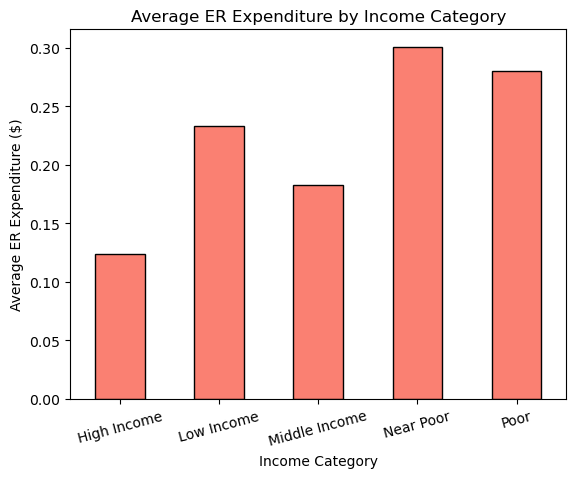

In [18]:
# Clean variables
df["ERTOT21"] = df["ERTOT21"].replace([-1, -7, -8, -9], pd.NA)
df["POVCAT21"] = df["POVCAT21"].replace([-1, -7, -8, -9], pd.NA)

# Overall average & median ER expenditure
average_er = df["ERTOT21"].mean()
median_er = df["ERTOT21"].median()

# % of people with zero ER spending
zero_er_pct = (df["ERTOT21"] == 0).mean() * 100

print(f"Average ER Expenditure per Person: ${average_er:,.2f}")
print(f"Median ER Expenditure per Person: ${median_er:,.2f}")
print(f"% of People with Zero ER Spending: {zero_er_pct:.1f}%")

# Map poverty categories
poverty_map = {
    1: "Poor",
    2: "Near Poor",
    3: "Low Income",
    4: "Middle Income",
    5: "High Income"
}
df["Poverty_Status"] = df["POVCAT21"].map(poverty_map)

# ER expenditure by income group
er_by_income = df.groupby("Poverty_Status")["ERTOT21"].mean()
print("\nAverage ER Expenditure by Income Group:")
print(er_by_income)

# Plot distribution by income
import matplotlib.pyplot as plt

er_by_income.plot(kind="bar", color="salmon", edgecolor="black")
plt.title("Average ER Expenditure by Income Category")
plt.xlabel("Income Category")
plt.ylabel("Average ER Expenditure ($)")
plt.xticks(rotation=15)
plt.show()

In [19]:
# Overall
# Most people have $0 ER expenditure → only a minority use ER services.
# Mean > Median → high-cost ER users skew the average.
# By Income
# Poor / Near-Poor often have slightly higher average ER costs relative to middle/high-income groups, due to higher reliance on ER for care.
# High-income groups generally have lower ER expenditures, relying more on office-based or preventive care.